# **Space Object Classification**

Data exploration.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

train_size = 0.70

cv_splits = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
randomState = 42
np.random.seed(randomState)

target = 'object_type'
url = '/content/Objects.csv'
df = pd.read_csv(url)
print(f'Data frame has {df.shape[0]} rows, and {df.shape[1]} columns')
display(df.head())
print(df.describe())
#no of rows with missing values
df.shape[0]-df.dropna().shape[0]
# to count no of missing values per columns
df.isna().sum()

Data frame has 45000 rows, and 12 columns


,objID,ra,dec,object_type,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,psfMag_r,clean,flags
0,1237655549129261058,238.593805,-1.027099,STAR,18.83619,17.39126,16.84484,16.58721,16.42528,16.84720,0,68988043776
1,1237655549129261061,238.608517,-1.151029,STAR,17.69599,15.95406,15.20453,14.89701,14.71652,15.20235,0,35255507619856
2,1237655549129261062,238.610665,-1.153622,STAR,23.98905,21.79921,20.66975,20.08602,19.87255,20.65793,0,72092847398064400
3,1237655549129261063,238.610172,-1.151936,STAR,24.82423,22.88640,21.99629,20.75805,20.33451,21.99124,0,105622137864464
4,1237655549129261067,238.611385,-0.966862,STAR,18.24983,16.83682,16.27165,16.05263,15.93228,16.27257,0,68988043776


              objID            ra           dec    modelMag_u    modelMag_g  \
count  4.500000e+04  45000.000000  45000.000000  45000.000000  45000.000000   
mean   1.237664e+18    216.294490     13.759100     22.491976     21.129724   
std    8.773402e+12    103.963128     20.585502     47.293470      2.109492   
min    1.237646e+18     20.245382     -9.343143  -9999.000000     11.095410   
25%    1.237658e+18    118.563706     -1.035420     21.570242     20.004088   
50%    1.237663e+18    232.899135      5.099052     22.924175     21.604650   
75%    1.237669e+18    314.059967     28.501807     24.230153     22.528487   
max    1.237680e+18    351.590282     75.861250     31.617690     31.454330   

         modelMag_r    modelMag_i    modelMag_z      psfMag_r         clean  \
count  45000.000000  45000.000000  45000.000000  45000.000000  45000.000000   
mean      19.957081     19.446713     19.191770     20.242210      0.323578   
std        1.780717      1.790101      1.850252    

,0
objID,0
ra,0
dec,0
object_type,0
modelMag_u,0
modelMag_g,0
modelMag_r,0
modelMag_i,0
modelMag_z,0
psfMag_r,0


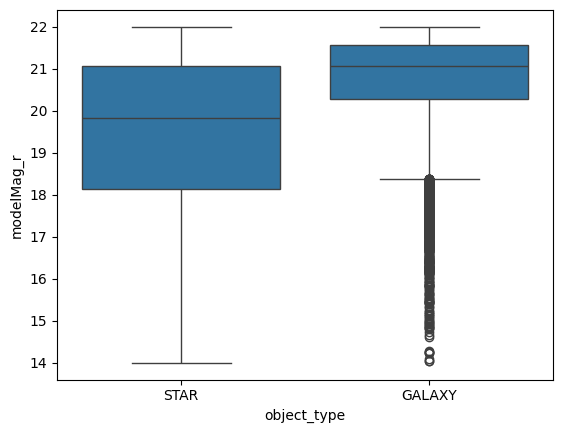

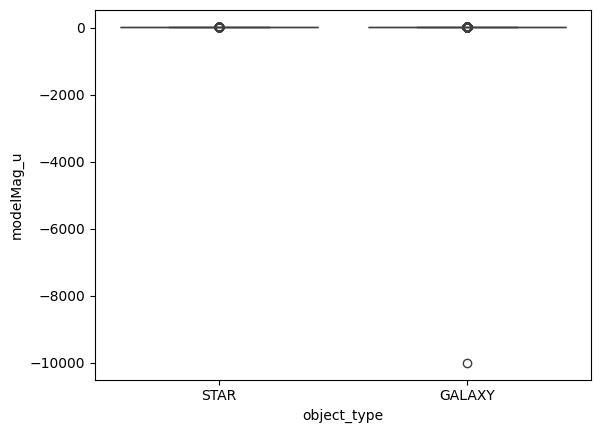

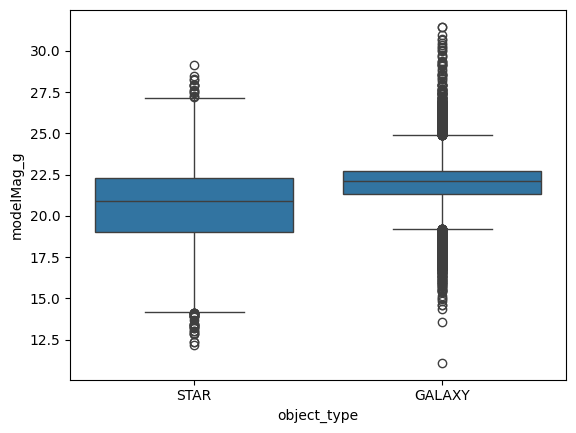

In [ ]:
sns.boxplot(x='object_type', y='modelMag_r', data=df)
plt.show()
sns.boxplot(x='object_type', y='modelMag_u', data=df)
plt.show()
sns.boxplot(x='object_type', y='modelMag_g', data=df)
plt.show()

DATA PREPROCESSING

In [ ]:
df = df.drop(['objID', 'flags'], axis=1)
df = df[df['clean'] == 1]
df = df.drop(['clean'], axis=1)

In [ ]:
# drop missing values
df = df.dropna()
print(f'there are {df.isna().sum().sum()} rows with null values')


there are 0 rows with null values


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
column_to_transform = target
transofermed_column = le.fit_transform(df[column_to_transform])
df[column_to_transform] = transofermed_column


In [ ]:
#split data frame in X features and target
X = df.drop(target,axis=1)
X.shape


(14561, 8)

In [ ]:
Y = df[target]
Y.shape

(14561,)

Encode labels, Models don’t understand text like “STAR”

In [ ]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, Y, train_size=train_size, random_state=randomState)
print(Xtrain.shape, Xtest.shape, ytrain.shape, ytest.shape)

(10192, 8) (4369, 8) (10192,) (4369,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [ ]:
#import the classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier

In [ ]:
# set classifier labels and their parameters for grid search
model_lbls = [
    'dt',
    'nb',
    'perceptron',
    'knn',
    'ada',
    'rf'
]

param_dt = [{'max_depth':[*range(1,20)],'class_weight':[None,'balanced']}]
param_nb = [{'var_smoothing':[10**exp for exp in range(-3,-12,-1)]}]
param_perceptron = [{'early_stopping':[True,False],'class_weight':[None,'balanced']}]
param_knn = [{'n_neighbors':[*range(2,7)]}]
param_ada = [{'n_estimators':[10,20,30,40,50],'learning_rate':[0.5,0.75,1,1.25,1.5]}]
param_rf = [{'n_estimators':[*range(10,30,4)],'max_depth':[*range(5,30,3)], 'class_weight':[None,'balanced']}]

models = {
    'dt':{
        'name':'Decision Tree',
        'estimator':DecisionTreeClassifier(random_state=randomState),
        'params':param_dt
    },
    'nb':{
        'name':'Gaussian Naive Bayes',
        'estimator':GaussianNB(),
        'params':param_nb
    },
    'perceptron':{
        'name':'Perceptron',
        'estimator':Perceptron(random_state=randomState),
        'params':param_perceptron
    },
    'knn':{
        'name':'K-Nearest Neighbors',
        'estimator':KNeighborsClassifier(),
        'params':param_knn
        },
    'ada':{
        'name':'AdaBoost',
        'estimator':AdaBoostClassifier(random_state=randomState),
        'params':param_ada
    },
    'rf':{
        'name':'Random Forest',
        'estimator':RandomForestClassifier(random_state=randomState),
        'params':param_rf
    }

}

In [ ]:
#define the scoring metrics
scorings = ['accuracy','precision_macro','recall_macro','f1_macro']
clfs = []
results = pd.DataFrame(columns=['scoring','model','best_params','accuracy','precision_macro','recall_macro','f1_macro'])


In [ ]:
#test and train the classifier with grid search for each scoring
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

for scoring in scorings:
  for m in model_lbls:
    clf = GridSearchCV(
        estimator=models[m]['estimator'],
        param_grid=models[m]['params'],
        scoring=scoring,
        cv=cv_splits,
    )
    clf.fit(Xtrain, ytrain)
    clfs.append(clf.best_estimator_)
    y_pred = clf.predict(Xtest)
    cr = classification_report(ytest, y_pred, output_dict=True, zero_division=1)
    results.loc[len(results)] = [
        scoring,
        models[m]['name'],
        clf.best_params_,
        cr['accuracy'],
        cr['macro avg']['precision'],
        cr['macro avg']['recall'],
        cr['macro avg']['f1-score']
    ]

In [ ]:
# display the results for each scoring metric
for score in scorings:
    display(
        results[results.scoring==score]\
            .sort_values(by=score,ascending=False)\
            .drop('scoring',axis=1)\
            .style.format(precision=3)\
            .set_caption(f'Best Models for:{score}')
    )

,model,best_params,accuracy,precision_macro,recall_macro,f1_macro
16,Random Forest,"{'class_weight': None, 'max_depth': 26, 'n_estimators': 26}",0.944,0.943,0.934,0.938
5,Random Forest,"{'class_weight': None, 'max_depth': 26, 'n_estimators': 26}",0.944,0.943,0.934,0.938
0,Decision Tree,"{'class_weight': None, 'max_depth': 9}",0.942,0.939,0.934,0.936
11,Decision Tree,"{'class_weight': None, 'max_depth': 9}",0.942,0.939,0.934,0.936
2,Perceptron,"{'class_weight': None, 'early_stopping': False}",0.940,0.930,0.942,0.936
13,Perceptron,"{'class_weight': None, 'early_stopping': False}",0.940,0.930,0.942,0.936
15,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.904,0.904,0.882,0.891
4,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.904,0.904,0.882,0.891
14,K-Nearest Neighbors,{'n_neighbors': 5},0.880,0.873,0.859,0.865
3,K-Nearest Neighbors,{'n_neighbors': 5},0.880,0.873,0.859,0.865


,model,best_params,accuracy,precision_macro,recall_macro,f1_macro
6,Decision Tree,"{'class_weight': None, 'max_depth': 9}",0.942,0.939,0.934,0.936
17,Decision Tree,"{'class_weight': None, 'max_depth': 9}",0.942,0.939,0.934,0.936
22,Random Forest,"{'class_weight': None, 'max_depth': 14, 'n_estimators': 18}",0.936,0.934,0.924,0.929
19,Perceptron,"{'class_weight': None, 'early_stopping': False}",0.940,0.930,0.942,0.936
8,Perceptron,"{'class_weight': None, 'early_stopping': False}",0.940,0.930,0.942,0.936
21,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.904,0.904,0.882,0.891
10,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.904,0.904,0.882,0.891
20,K-Nearest Neighbors,{'n_neighbors': 5},0.880,0.873,0.859,0.865
9,K-Nearest Neighbors,{'n_neighbors': 5},0.880,0.873,0.859,0.865
7,Gaussian Naive Bayes,{'var_smoothing': 0.001},0.689,0.713,0.730,0.687


,model,best_params,accuracy,precision_macro,recall_macro,f1_macro
25,Perceptron,"{'class_weight': None, 'early_stopping': False}",0.940,0.930,0.942,0.936
23,Decision Tree,"{'class_weight': None, 'max_depth': 9}",0.942,0.939,0.934,0.936
28,Random Forest,"{'class_weight': None, 'max_depth': 26, 'n_estimators': 26}",0.944,0.943,0.934,0.938
27,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.904,0.904,0.882,0.891
26,K-Nearest Neighbors,{'n_neighbors': 4},0.882,0.868,0.877,0.872
24,Gaussian Naive Bayes,{'var_smoothing': 0.001},0.689,0.713,0.730,0.687


,model,best_params,accuracy,precision_macro,recall_macro,f1_macro
34,Random Forest,"{'class_weight': None, 'max_depth': 26, 'n_estimators': 26}",0.944,0.943,0.934,0.938
29,Decision Tree,"{'class_weight': None, 'max_depth': 9}",0.942,0.939,0.934,0.936
31,Perceptron,"{'class_weight': None, 'early_stopping': False}",0.940,0.930,0.942,0.936
33,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 50}",0.904,0.904,0.882,0.891
32,K-Nearest Neighbors,{'n_neighbors': 6},0.884,0.872,0.876,0.874
30,Gaussian Naive Bayes,{'var_smoothing': 0.001},0.689,0.713,0.730,0.687


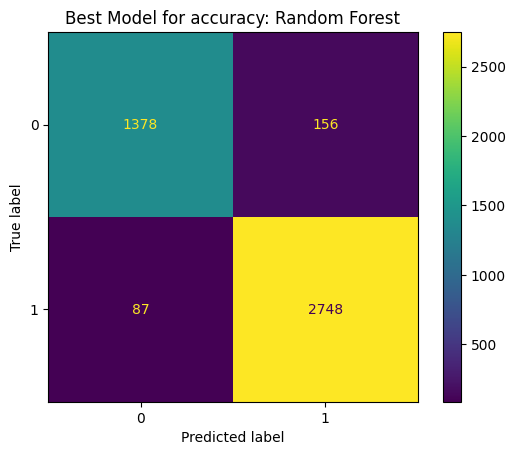

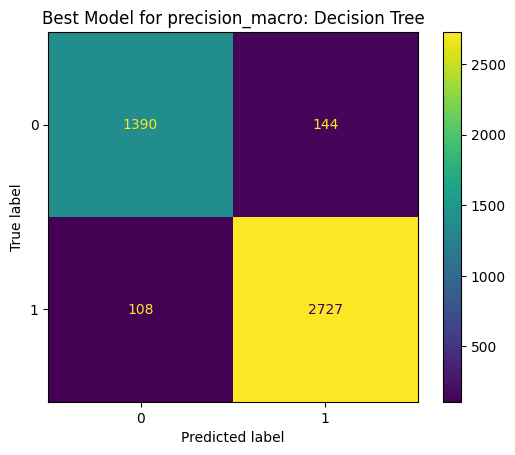

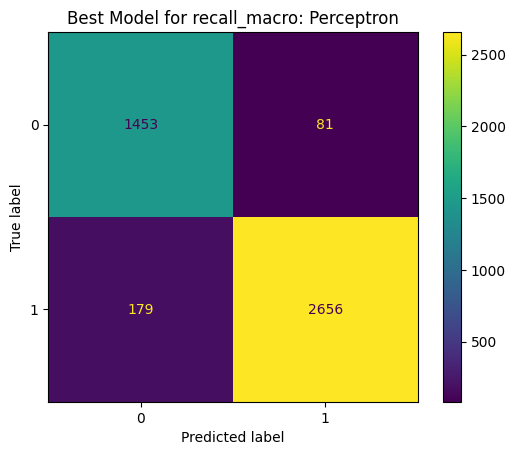

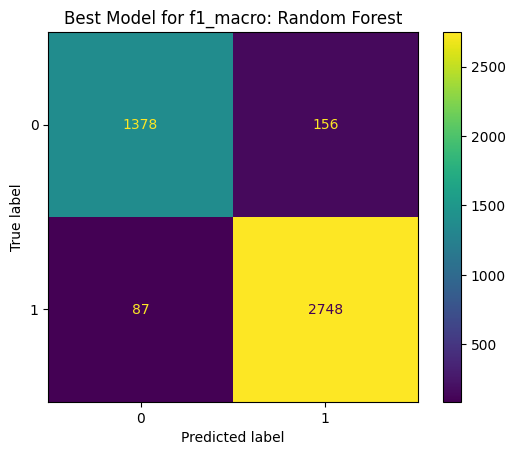

In [ ]:
# display the confusion matrix for the best model for each scoring metric
from sklearn.metrics import ConfusionMatrixDisplay

for score in scorings:
    scoring_filter = score
    best_row = results.loc[results.scoring==scoring_filter,scoring_filter].idxmax(axis=0)
    disp = ConfusionMatrixDisplay.from_estimator(X=Xtest, y=ytest, estimator = clfs[best_row])
    disp.ax_.set_title("Best Model for {}: {}".format(score,results.at[best_row,'model']))